# BUSINESS DATA ANALYTICS APPLIED LAB 2: RISK MANAGEMENT & OSH ANALYTICS
Un conglomerado de 150 empresas está alarmado por el aumento en los reportes de accidentes laborales. El costo de las incapacidades y el impacto humano están afectando la productividad global. La gerencia no solo necesita saber cuántos accidentes ocurren, sino que requiere identificar patrones de riesgo para implementar una estrategia de prevención. Su misión como analista de datos consiste en aplicar la metodología CRISP-DM para consolidar fuentes de datos dispersas, generar evidencia visual sobre los factores de riesgo (jornada, capacitación y sector) y proponer reglas de negocio preventivas.

_Actualizado: 16/02/2026_
_ebuitragob@ucentral.edu.co_

## Carga y transformación datos

In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Paso 1: Carga y Preparación de Datos (Data Understanding)

df_trabajadores = pd.read_csv('trabajadores.csv', index_col=0)
df_empresas = pd.read_csv('empresas.csv', index_col=0)
df_accidentes = pd.read_csv('accidentes.csv', index_col=0)


In [3]:
# Paso 2: Consolidación de Información (Data Preparation / Triple Join)
# Unimos trabajadores con empresas
df_merge = pd.merge(df_trabajadores, df_empresas, left_on='empresa', right_on='id_empresa')

# Unir con accidentes (Left join para no perder a quienes NO tuvieron accidentes)
df_final = pd.merge(df_merge, df_accidentes, on='id_trabajador', how='left')

# Crear variable binaria: 1 si hubo accidente, 0 si no
df_final['incidente'] = df_final['id_accidente'].notnull().astype(int)

## Visualización

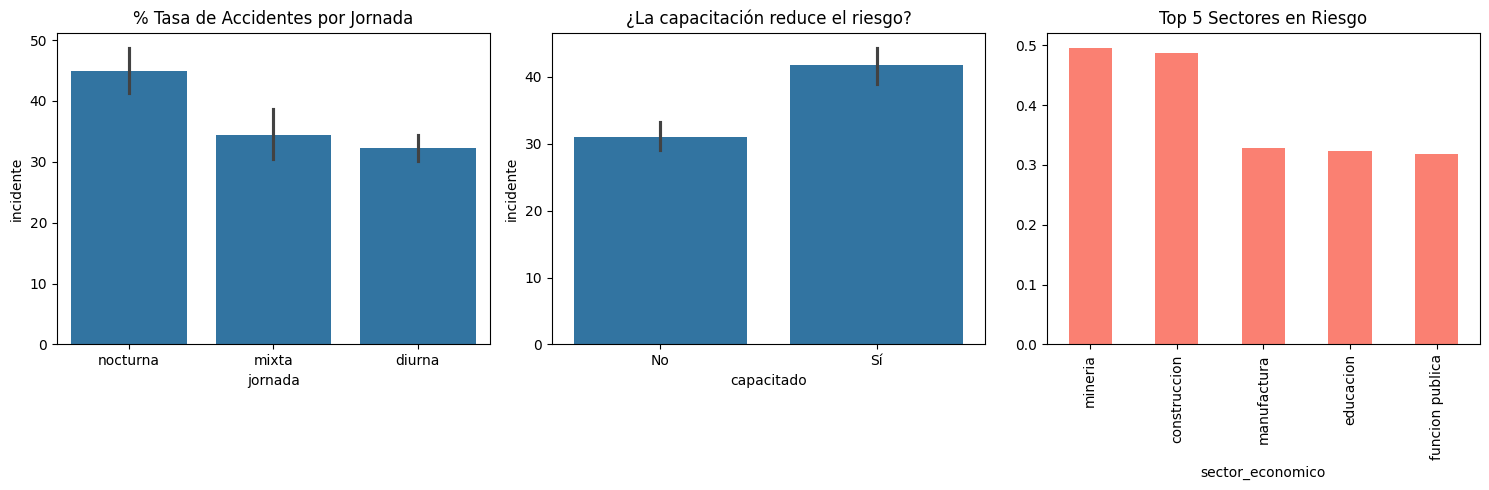

In [4]:
# Paso 3: Modelado Descriptivo (Visualización de Evidencia)
plt.figure(figsize=(15, 5))

# Gráfico 1: Riesgo por Jornada
plt.subplot(1, 3, 1)
sns.barplot(data=df_final, x='jornada', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.title('% Tasa de Accidentes por Jornada')

# Gráfico 2: Impacto de la Capacitación
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='capacitado', y='incidente', estimator=lambda x: sum(x)/len(x)*100)
plt.xticks([0, 1], ['No', 'Sí'])
plt.title('¿La capacitación reduce el riesgo?')

# Gráfico 3: Sectores más críticos (Top 5)
plt.subplot(1, 3, 3)
df_final.groupby('sector_economico')['incidente'].mean().sort_values(ascending=False).head(5).plot(kind='bar', color='salmon')
plt.title('Top 5 Sectores en Riesgo')

plt.tight_layout()
plt.show()

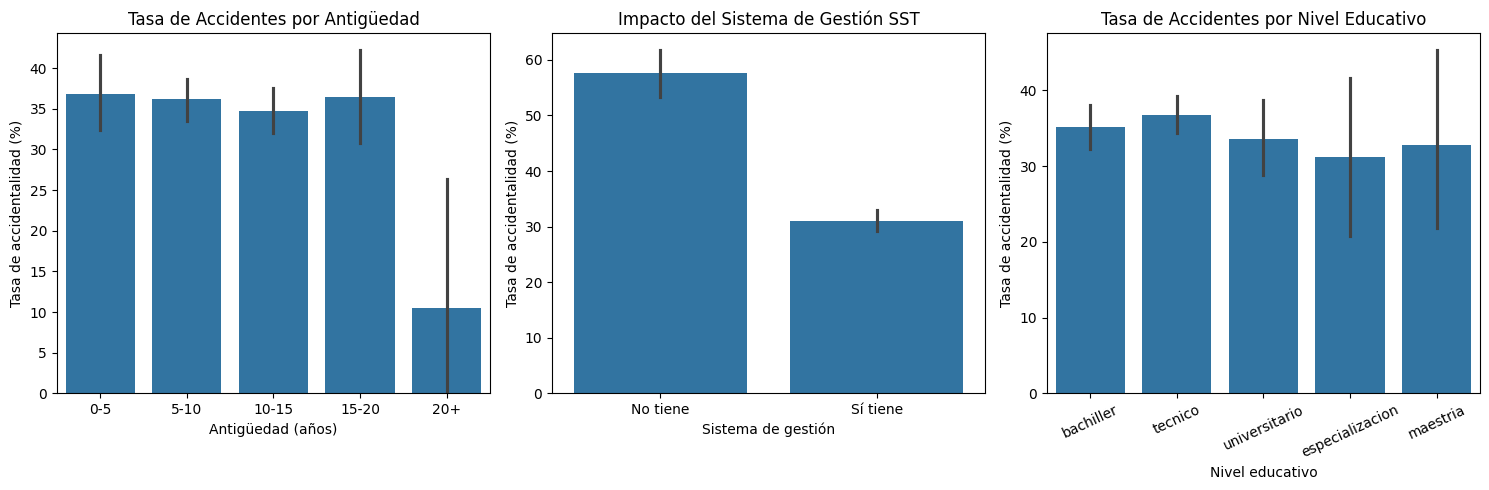

In [5]:
# --- SECCIÓN DE EXPLORACIÓN AUTÓNOMA ---
# Se profundiza el análisis explorando: antigüedad, sistema de gestión SST
# y nivel educativo frente a la variable 'incidente'.

# Variable derivada: bucket de antigüedad (0-5, 5-10, 10-15, 15-20, 20+ años)
df_final['antiguedad_bucket'] = pd.cut(
    df_final['antiguedad'], bins=[-0.1, 5, 10, 15, 20, 100],
    labels=['0-5', '5-10', '10-15', '15-20', '20+'])

plt.figure(figsize=(15, 5))

# Gráfico 4: Antigüedad vs. accidentalidad
plt.subplot(1, 3, 1)
sns.barplot(data=df_final, x='antiguedad_bucket', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100,
            order=['0-5', '5-10', '10-15', '15-20', '20+'])
plt.title('Tasa de Accidentes por Antigüedad')
plt.ylabel('Tasa de accidentalidad (%)')
plt.xlabel('Antigüedad (años)')

# Gráfico 5: Sistema de gestión SST vs. accidentalidad
plt.subplot(1, 3, 2)
sns.barplot(data=df_final, x='sistema_gestion', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100)
plt.xticks([0, 1], ['No tiene', 'Sí tiene'])
plt.title('Impacto del Sistema de Gestión SST')
plt.ylabel('Tasa de accidentalidad (%)')
plt.xlabel('Sistema de gestión')

# Gráfico 6: Nivel educativo vs. accidentalidad
plt.subplot(1, 3, 3)
orden_educ = ['bachiller', 'tecnico', 'universitario', 'especializacion', 'maestria']
sns.barplot(data=df_final, x='nivel_educativo', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100, order=orden_educ)
plt.title('Tasa de Accidentes por Nivel Educativo')
plt.ylabel('Tasa de accidentalidad (%)')
plt.xlabel('Nivel educativo')
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


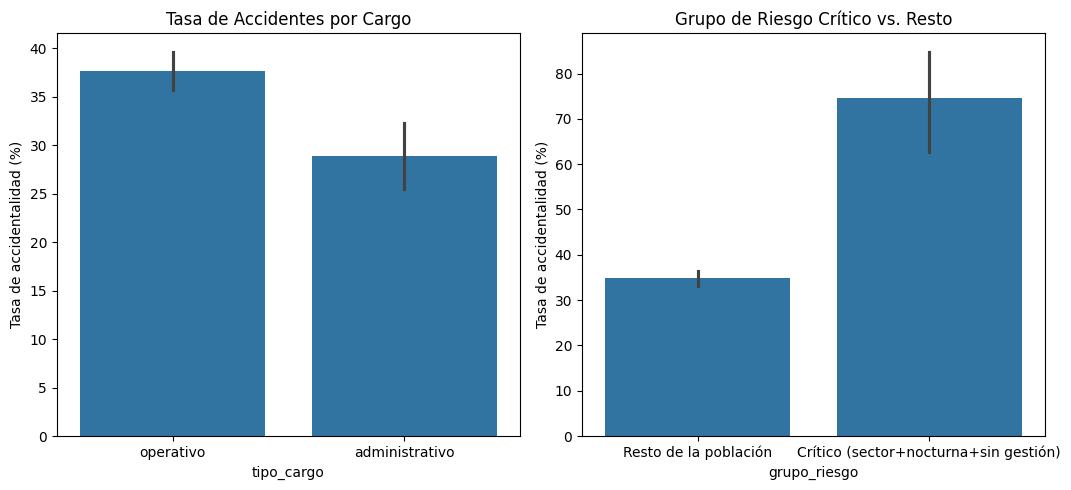

Tasa de accidentalidad - grupo crítico vs. resto:
grupo_riesgo
Crítico (sector+nocturna+sin gestión)    74.576271
Resto de la población                    34.784087
Name: incidente, dtype: float64


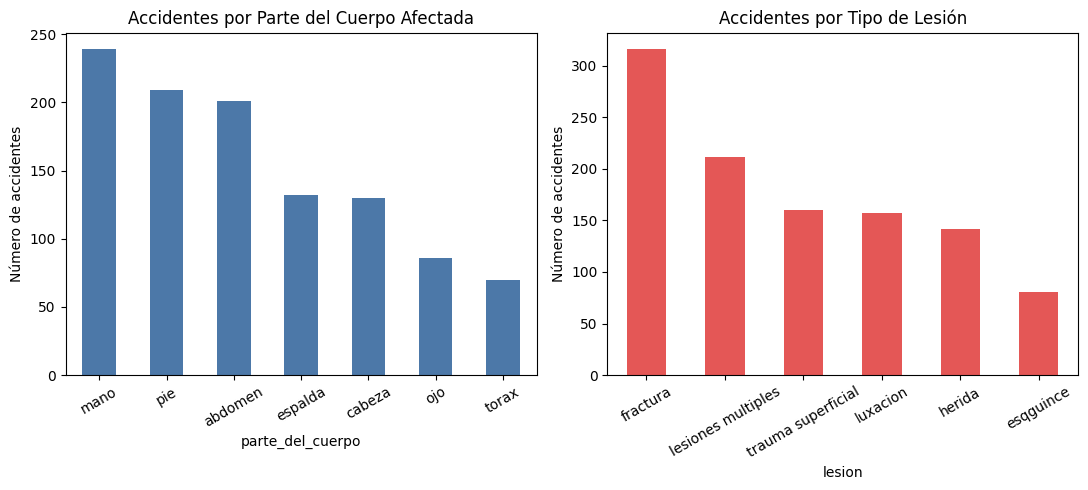

In [6]:
# Gráfico adicional 1: Cargo y "grupo de riesgo crítico"
# (sector minería/construcción + jornada nocturna + sin sistema de gestión)
plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=df_final, x='tipo_cargo', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100)
plt.title('Tasa de Accidentes por Cargo')
plt.ylabel('Tasa de accidentalidad (%)')

df_final['sector_critico'] = df_final['sector_economico'].isin(['mineria', 'construccion'])
df_final['grupo_riesgo'] = df_final.apply(
    lambda r: 'Crítico (sector+nocturna+sin gestión)'
    if (r['sector_critico'] and r['jornada'] == 'nocturna' and r['sistema_gestion'] == 0)
    else 'Resto de la población', axis=1)

plt.subplot(1, 2, 2)
sns.barplot(data=df_final, x='grupo_riesgo', y='incidente',
            estimator=lambda x: sum(x)/len(x)*100)
plt.title('Grupo de Riesgo Crítico vs. Resto')
plt.ylabel('Tasa de accidentalidad (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("Tasa de accidentalidad - grupo crítico vs. resto:")
print(df_final.groupby('grupo_riesgo')['incidente'].mean() * 100)

# Gráfico adicional 2: naturaleza de los accidentes (solo trabajadores accidentados)
plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
df_accidentes['parte_del_cuerpo'].value_counts().plot(kind='bar', color='#4C78A8')
plt.title('Accidentes por Parte del Cuerpo Afectada')
plt.ylabel('Número de accidentes')
plt.xticks(rotation=30)

plt.subplot(1, 2, 2)
df_accidentes['lesion'].value_counts().plot(kind='bar', color='#E45756')
plt.title('Accidentes por Tipo de Lesión')
plt.ylabel('Número de accidentes')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


## Análisis

**Jornada:** la tasa de accidentalidad es notablemente más alta en jornada nocturna (45,0%) que en
diurna (32,3%) o mixta (34,5%), lo que confirma que la fatiga, la baja visibilidad y la menor
supervisión asociadas al turno nocturno son un factor de riesgo real.

**Capacitación:** contra lo esperado, los trabajadores capacitados presentan una tasa de accidentalidad
mayor (41,7%) que los no capacitados (31,0%). Esto sugiere **causalidad inversa**: las empresas
capacitan preferentemente al personal que ya ocupa los cargos y sectores de mayor exposición
(operativo, minería, construcción), por lo que la capacitación actúa hoy como una respuesta reactiva
y no como un control preventivo estructural.

**Sistema de gestión SST:** es el factor individual con mayor poder explicativo — 57,6% de
accidentalidad sin sistema de gestión frente a 31,1% con sistema de gestión (-26,5 p.p.), muy por
encima del efecto de cualquier variable del perfil del trabajador.

**Antigüedad:** la accidentalidad se mantiene alta y estable entre 0 y 20 años de experiencia
(34,7%-36,8%) y cae drásticamente a 10,5% después de los 20 años, lo que evidencia un fuerte efecto
de la pericia acumulada sobre la prevención de accidentes.

**Nivel educativo:** es un factor secundario, con un gradiente leve entre niveles (técnico 36,7%
frente a especialización 31,2%).

**Sector y cargo:** minería (49,6%) y construcción (48,6%) son los sectores más críticos, casi
duplicando sectores como manufactura o educación (~32%). Los cargos operativos (37,6%) superan a
los administrativos (28,9%). Al combinar sector crítico + jornada nocturna + ausencia de sistema de
gestión, se identifica un **grupo de riesgo crítico con 74,6% de accidentalidad**, más del doble que
el resto de la población (34,8%).

**Naturaleza de los accidentes:** la lesión más frecuente es la fractura (30% de los casos),
seguida de lesiones múltiples y trauma superficial. Mano, pie y abdomen son las partes del cuerpo
más afectadas, lo que sugiere reforzar el uso de equipo de protección personal en esas zonas.


## Conclusiones

1. El **sistema de gestión SST** es la palanca de mayor impacto para reducir la accidentalidad
   (-26,5 p.p.), muy por encima de cualquier característica individual del trabajador.
2. La **jornada nocturna** y los **sectores de minería y construcción** son los factores de mayor
   riesgo operativo, y su combinación con la ausencia de sistema de gestión eleva la accidentalidad
   hasta el 74,6%.
3. La **capacitación**, tal como se aplica hoy, es reactiva (se concentra en el personal ya expuesto)
   y no está funcionando como control preventivo; debe rediseñarse como requisito habilitante
   *antes* de asignar turnos o tareas de riesgo, no como respuesta posterior al incidente.
4. La **experiencia (antigüedad > 20 años)** reduce drásticamente el riesgo, lo que sugiere que los
   programas de mentoría y transferencia de conocimiento entre trabajadores senior y junior pueden
   ser una estrategia de prevención adicional de bajo costo.
5. Las fracturas y lesiones en mano, pie y abdomen concentran la mayoría de los casos, un insumo
   útil para priorizar los elementos de protección personal (EPP) por sector.
6. Se recomienda implementar la regla de negocio automática descrita en el reporte ejecutivo
   (sector crítico + jornada nocturna + sin sistema de gestión → bloqueo preventivo y escalamiento),
   priorizando la certificación de sistemas de gestión SST en las empresas del conglomerado.
